Dieser Codeblock lädt die genutzten Bibliotheken, Funktionen und Daten in den Arbeitsspeicher. 

In [1]:
import importlib
import imageFunctions
importlib.reload(imageFunctions)

from imageFunctions import preprocessImage
from imageFunctions import processImage
from imageFunctions import readImage
from imageFunctions import visualizeDecision
from imageFunctions import featureProcessing

import cv2
from pathlib import Path
import pickle
import numpy as np

with open('finishedData/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('finishedData/pca.pkl', 'rb') as f:
    pca = pickle.load(f)

In diesem Codeblock werden die Modelle geladen, der Pfad für das Video als Input erstellt, sowie die Koordinaten für das Zielfeld definiert.

In [2]:
targetPath = Path().cwd().parent / 'data' / 'deployment_videos' / 'pitting_video.mp4'
modelPath = Path().cwd() / 'trainedModels'

rCoords = (680,470,190,190) #(x,y,w,h)

with open(modelPath / 'decisionTreeUnsimplified.pkl', 'rb') as f:
    decTree = pickle.load(f)

with open(modelPath / 'XGBBoostUnsimplified.pkl', 'rb') as f:
    gradBoost = pickle.load(f)

Dieser Codeblock enthält die genutzte Funktion, um in jedem Frame im Video das Zielfeld auszuwählen, mit dem jeweiligen Klassifikator die Vorhersage durchzuführen, anhand dessen die Ergebnisse auf dem Frame darzustellen und speichert das so erstellte Video ab.

In [12]:
def workWithVideo (model, inputPath, outputPath):
    cap = cv2.VideoCapture(str(inputPath))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Or 'mp4v' for .mp4 output
    out = cv2.VideoWriter(str(outputPath), fourcc, fps, (width, height))

    frameCount = 0

    while cap.isOpened():
        ret, frame = cap.read()

        if not ret:
            break
        region = frame[rCoords[1]:rCoords[1]+rCoords[3],rCoords[0]:rCoords[0]+rCoords[2]]
        gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
        image = preprocessImage(gray)
        feature = processImage(image)
        importantFeature = featureProcessing(feature, pca, scaler)

        probs = model.predict_proba(importantFeature)
        predLabel = np.argmax(probs)
        predProb = probs[0][predLabel]

        color = (0, 255, 0) if predLabel == 0 else (255,0,0)

        cv2.rectangle(frame,
                    (rCoords[0], rCoords[1]),
                    (rCoords[0]+rCoords[2], rCoords[1]+rCoords[3]),
                    color, 2)
        
        label = f"{'Pitting' if predLabel == 1 else 'No Pitting'} ({predProb:.3f})"
        cv2.putText(frame, label, (rCoords[0], rCoords[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        out.write(frame)
        frameCount += 1

    cap.release()
    out.release()


Hier wird die vorangegangen erklärte Funktion für beide Modelle aufgerufen.

In [17]:
resultPath = Path().cwd() / 'resultVideos' / 'pittingResultRandomForest.mp4'
workWithVideo(decTree, targetPath, resultPath)

resultPath = Path().cwd() / 'resultVideos' / 'pittingResultGradientBoost.mp4'
workWithVideo(gradBoost, targetPath, resultPath)

Diese Funktion wird genutzt, um den Aufruf mit einem Modell zu verschlanken, wenn ein einzelnes Bild untersucht wird.

In [3]:
def makePredicion (model, feature):
    propability = model.predict_proba(feature)
    label = np.argmax(propability)
    predictionPropa = propability[0][label]
    if label == 1: label = 'True'
    else: label = 'False'
    return (label, predictionPropa)

Der folgende Codeblock erstellt aus dem Benchmarkbild das zu untersuchende Feature, führt die Vorhersage auf dem Bild mit beiden Modellen durch und visualisiert die jeweiligen Ergebnisse zum visuellen Vergleich mit den CNN Algorithmen. Die erstellten bilder gelten ausschließlich der Visualisierung.

using random forest: 
pitting: True, propability: 0.605



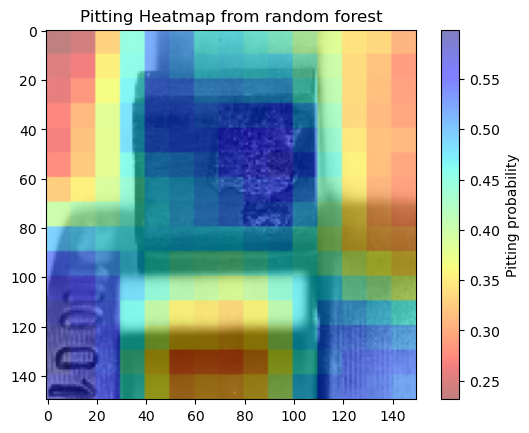

using gradient boosting: 
pitting: True, propability: 0.894


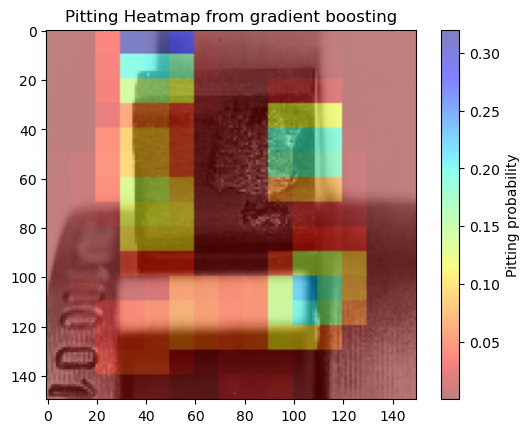

In [4]:
targetPath = Path().cwd().parent / 'data' / 'Oel_pit_h.jpg'
testImage = readImage(targetPath)
feature = featureProcessing(processImage(preprocessImage(testImage)), pca, scaler)

predLabel, predProb = makePredicion(decTree, feature)
print(f"using random forest: \npitting: {predLabel}, propability: {predProb:.3f}\n")
visualizeDecision(readImage(targetPath), decTree, 'random forest', pca, scaler)

predLabel, predProb = makePredicion(gradBoost, feature)
print(f"using gradient boosting: \npitting: {predLabel}, propability: {predProb:.3f}")
visualizeDecision(readImage(targetPath), gradBoost, 'gradient boosting', pca, scaler)

Dieser Codeblock ist identisch zum letzten, bis auf das zu klassifizierende Bild. 

using random forest: 
pitting: True, propability: 0.864



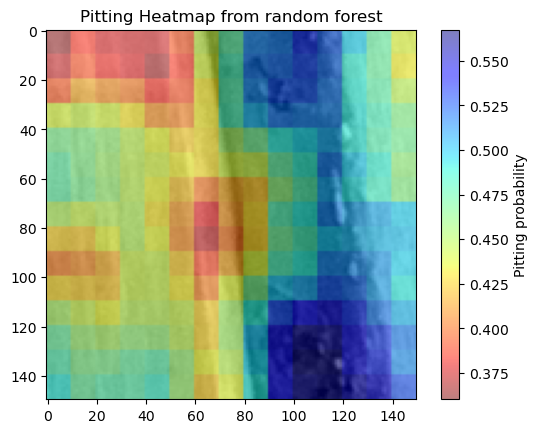

using gradient boosting: 
pitting: True, propability: 1.000


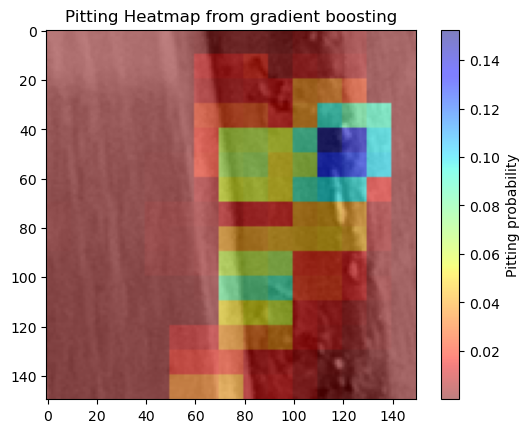

: 

In [ ]:
targetPath = Path().cwd().parent / 'data' / 'KGT_pitting' /'P (2).png'
testImage = readImage(targetPath)
feature = featureProcessing(processImage(preprocessImage(testImage)), pca, scaler)

predLabel, predProb = makePredicion(decTree, feature)
print(f"using random forest: \npitting: {predLabel}, propability: {predProb:.3f}\n")
visualizeDecision(readImage(targetPath), decTree, 'random forest', pca, scaler)

predLabel, predProb = makePredicion(gradBoost, feature)
print(f"using gradient boosting: \npitting: {predLabel}, propability: {predProb:.3f}")
visualizeDecision(readImage(targetPath), gradBoost, 'gradient boosting', pca, scaler)